In [69]:
import folium as flm
import base64
import os
import geopandas as gpd


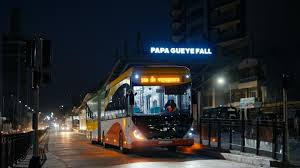
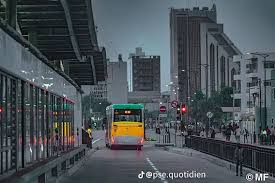
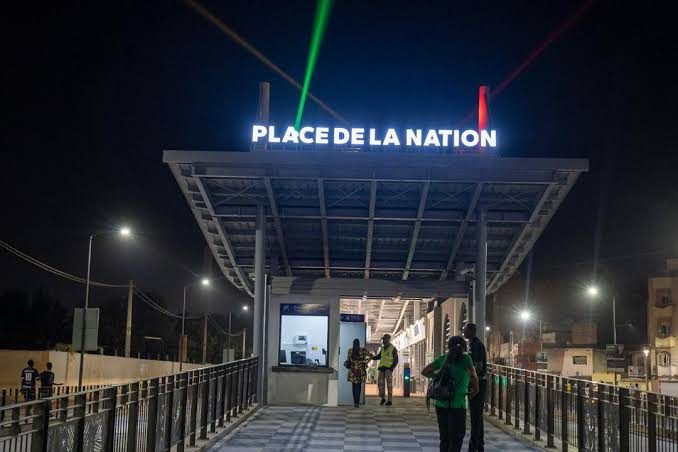
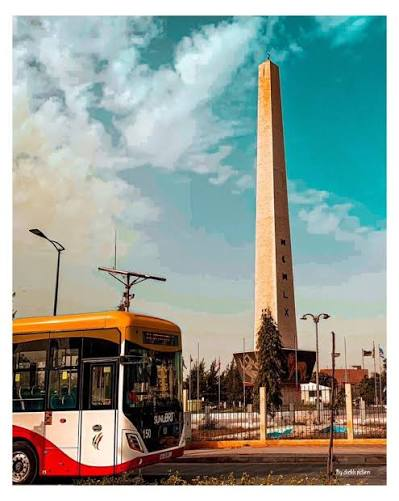
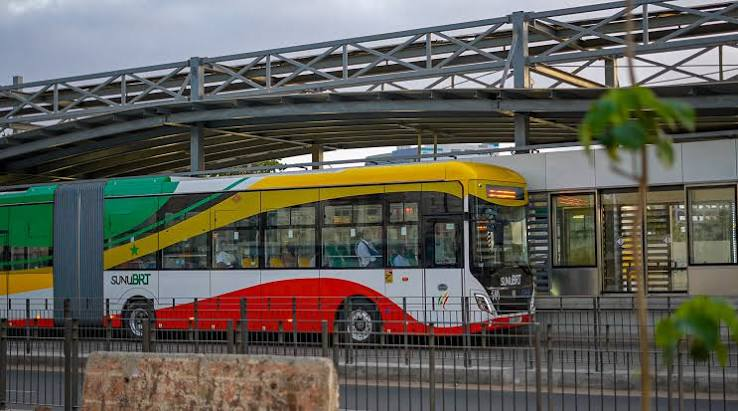
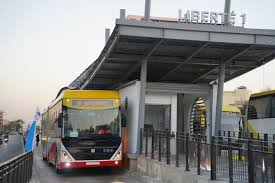
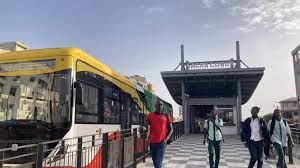
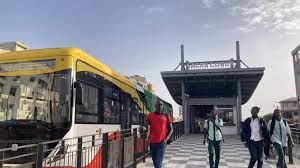
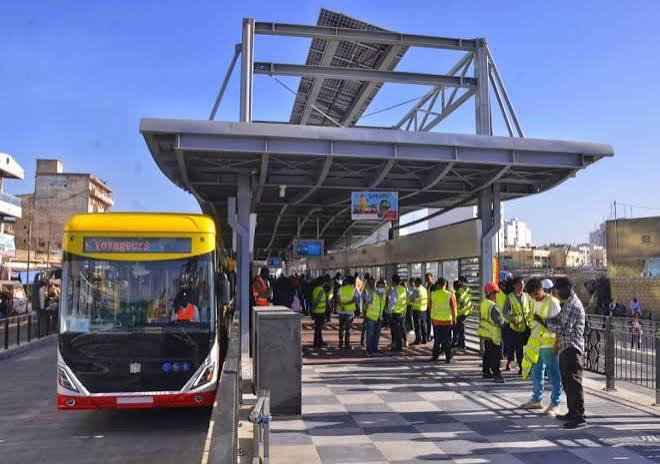
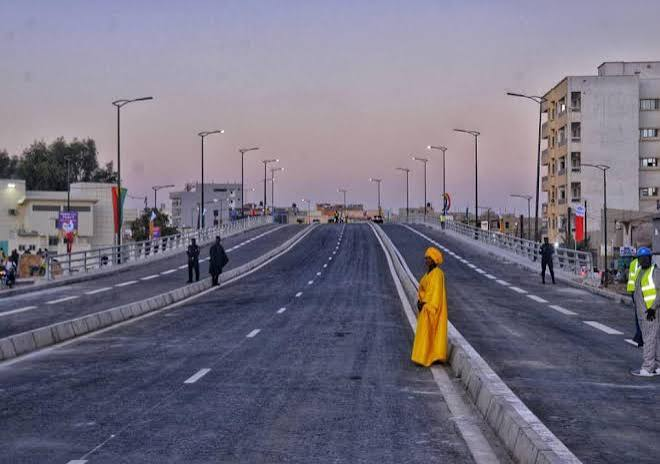
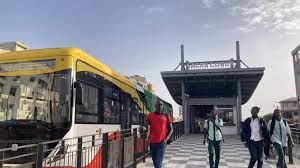
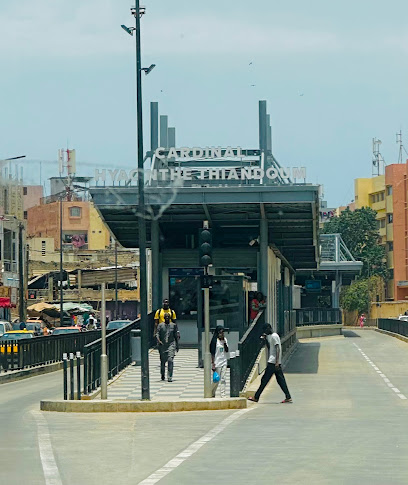
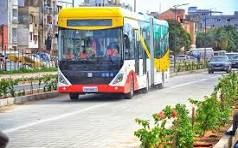
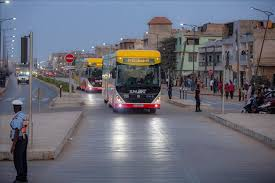
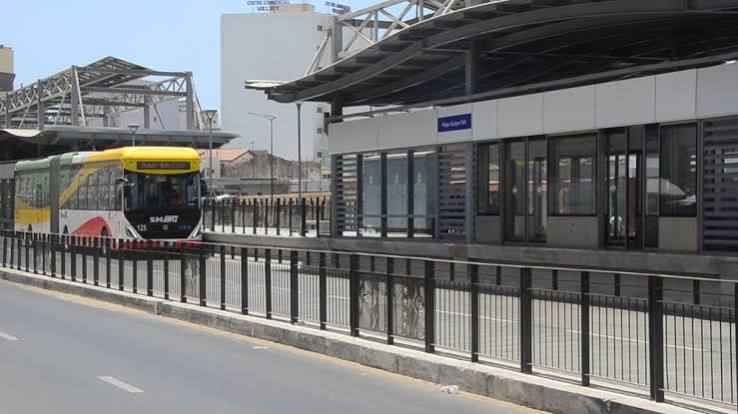
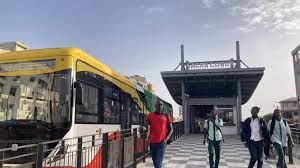
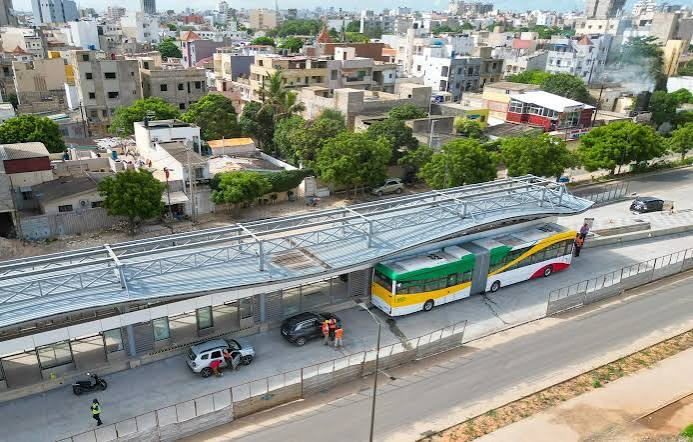
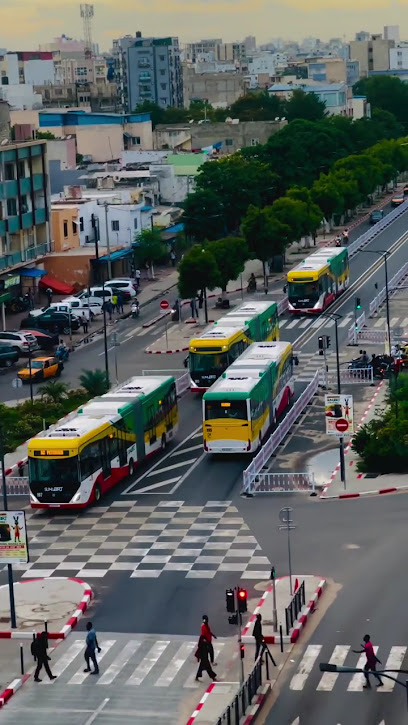
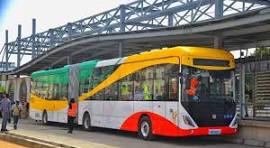
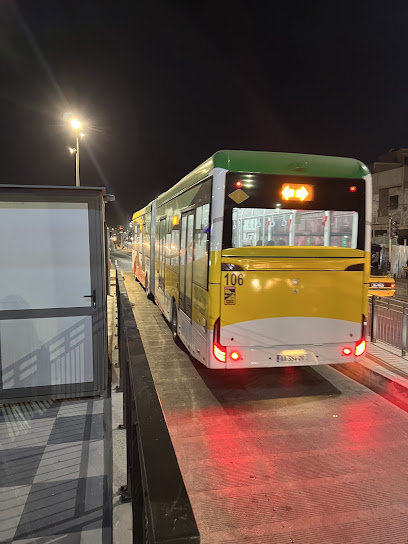
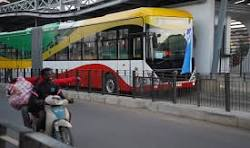
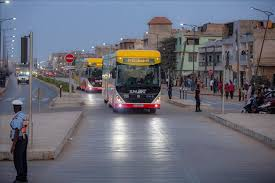
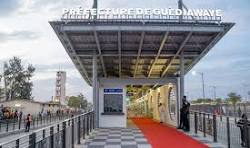

In [70]:
# FONCTION : Conversion d'une image locale en base64
# Permet d'intégrer les images directement dans le HTML du popup
def image_en_base64(chemin):
    if chemin and os.path.exists(chemin):
        with open(chemin, "rb") as f:
            data = base64.b64encode(f.read()).decode("utf-8")
        return f"data:image/jpeg;base64,{data}"
    return None  # Retourne None si le fichier est introuvable


# DONNÉES GÉOSPATIALES : Chargement des couches shapefile
Commune  = gpd.read_file("Communes_BRT.shp")
traceBRT = gpd.read_file("Trace_BRT.shp")


# DONNÉES DES ARRÊTS
# Format : (latitude, longitude, nom, couleur_marqueur,image, groupe)
arrets = [
    (14.67649976772359,  -17.440371813512336, "Pape Gueye Fall (Terminus)", "red",   "Pape_Gueye_Fall.jpg",       "ZONE PETERSEN"),
    (14.68253299329415,  -17.44422744672432,  "Arrêt Grande mosquée",       "red",   "Grande_mosquee.jpg",        "ZONE PETERSEN"),
    (14.695862419272004, -17.450349712630448, "Place de la nation",         "red",   "place_nation.jpg",          "ZONE PETERSEN"),
    (14.699357524898163, -17.45341776680979,  "Arrêt Dial Diop",            "red",   "dial_diop.jpg",             "ZONE PETERSEN"),
    (14.704481538180268, -17.457801578898323, "Grand Dakar",                "red",   "Grand_dakar.jpg",           "ZONE PETERSEN"),
    (14.70930283483048,  -17.461894526861567, "Liberté 1",                  "red",   "liberté 1.jpg",             "ZONE PETERSEN"),
    (14.716884067369449, -17.46649112790348,  "Sacré cœur",                 "red",   "Sacre coeur.jpg",           "ZONE PETERSEN"),
    (14.720773244574188, -17.464265137108743, "Liberté 5",                  "red",   "liberte5.jpg",              "ZONE PETERSEN"),
    (14.726044284517494, -17.459381909780713, "Liberté 6",                  "red",   "liberte6.jpg",              "ZONE PETERSEN"),
    (14.73435543990517,  -17.456077638586997, "Khar yalla",                 "green", "khar_yalla.jpg",            "ZONE GRAND-MEDINE"),
    (14.737012974042063, -17.45519143889348,  "Scat Urbam",                 "green", "scat_urbam.jpg",            "ZONE GRAND-MEDINE"),
    (14.741340784199947, -17.451552008961844, "Cardinal Hyacinthe Thiandoum","green","cardinal.jpg",              "ZONE GRAND-MEDINE"),
    (14.747697829844554, -17.444813555509185, "Grand Médine",               "green", "Grand_Medine.jpg",          "ZONE GRAND-MEDINE"),
    (14.750866300766406, -17.439385082735374, "Police Parcelle",            "green", "police_parcelle.jpg",       "ZONE GRAND-MEDINE"),
    (14.753722559444133, -17.433599511099164, "Croisement 22",              "green", "Croisement 22.jpg",         "ZONE GRAND-MEDINE"),
    (14.76196788572872,  -17.425441158792754, "Arrêt Parcelles Assainies",  "blue",  "parcelles_assainies.jpg",   "ZONE GUEDIAWAYE"),
    (14.764443510211882, -17.420328558631603, "Arrêt Ndingala",             "blue",  "ndingala.jpg",              "ZONE GUEDIAWAYE"),
    (14.767028438175862, -17.414132293202837, "Golf Sud",                   "blue",  "golf_sud.jpg",              "ZONE GUEDIAWAYE"),
    (14.771046869410027, -17.408673452306697, "Dalal Diam",                 "blue",  "dalal_diam.jpg",            "ZONE GUEDIAWAYE"),
    (14.775267637269838, -17.40619660007969,  "Fith mith",                  "blue",  "fith_mith.jpg",             "ZONE GUEDIAWAYE"),
    (14.776288725802107, -17.39874470994836,  "Golf Nord",                  "blue",  "golf_nord.jpg",             "ZONE GUEDIAWAYE"),
    (14.775835983089774, -17.392518948405993, "Gueule Tapée",               "blue",  "Gueule_Tapee.jpg",          "ZONE GUEDIAWAYE"),
    (14.77230418596642,  -17.387213531486555, "Terminus Guédiawaye",        "blue",  "Guediawaye.jpg",            "ZONE GUEDIAWAYE"),
]


# CRÉATION DE LA CARTE 
carte = flm.Map(
    location=[14.72, -17.43],
    zoom_start=12,
    min_zoom=10,
    max_zoom=25,
    control_scale=True,
    tiles=None)

# Titre de la carte 
titre_html = f"""
<div style="
    position: fixed;
    top: 10px;
    left: 18%;
    transform: translateX(-50%);
    z-index: 1000;
    background-color: white;
    padding: 10px 20px;
    border-radius: 8px;
    border: 2px solid #e67e22;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    text-align: center;
    font-family: Arial, sans-serif;
">
    <h3 style="margin:0 0 4px 0; color:#2c3e50;">🚌 Ligne BRT Dakar</h3>
    <p style="margin:0; font-size:12px; color:#555;">
        Petersen ↔ Guédiawaye &nbsp;|&nbsp; 23 stations &nbsp;|&nbsp; 18,3 km
    </p>
</div>
"""
# Information sur trajet
info_html = f"""
<div style="
    position: fixed;bottom: 40px;left: 15px;z-index: 1000;background-color: white;
    padding: 10px 14px;border-radius: 8px;border-left: 4px solid #e67e22;box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    font-family: Arial, sans-serif;font-size: 12px;color: #333;max-width: 200px;
">
    <b style="font-size:13px;">ℹ️ Informations</b>
    <hr style="margin:6px 0; border:none; border-top:1px solid #ddd;">
    <p style="margin:3px 0;">📅 <b>Mise en service :</b> 2024</p>
    <p style="margin:3px 0;">🕐 <b>Fréquence :</b> 5 min en heure de pointe</p>
    <p style="margin:3px 0;">⏱️ <b>Trajet complet :</b> 45 min</p>
</div>
"""
# Ajout des basemaps alternatifs 
flm.TileLayer(
    tiles="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
    attr="Google Hybride",
    name="Google Hybride",
    min_zoom=10,
    max_zoom=25
).add_to(carte)

flm.TileLayer(
    tiles="CartoDB positron",
    name="CartoDB positron",
    min_zoom=10,
    max_zoom=25
).add_to(carte)

# OpenStreetMap actif par défaut
flm.TileLayer(
    tiles="OpenStreetMap",
    name="OpenStreetMap",
    min_zoom=10,
    max_zoom=25
).add_to(carte)

# COUCHES GÉOGRAPHIQUES EN JSON
flm.GeoJson(Commune, name="Communes BRT",color="black",fill=False).add_to(carte)
flm.GeoJson(traceBRT,name="Tracé BRT",color="orange",weight=4,opacity=1,tooltip="Ligne BRT").add_to(carte)

# GROUPES DE COUCHES (FeatureGroup)
# Permettent d'activer/désactiver chaque zone dans le LayerControl
Section1 = flm.FeatureGroup(name="🔴 ZONE PETERSEN",     show=True)
Section2 = flm.FeatureGroup(name="🟢 ZONE GRAND-MEDINE",  show=True)
Section3 = flm.FeatureGroup(name="🔵 ZONE GUEDIAWAYE",    show=True)
groupes = {
    "ZONE PETERSEN":     Section1,
    "ZONE GRAND-MEDINE": Section2,
    "ZONE GUEDIAWAYE":   Section3,}

# Couleur des rectangles délimitant chaque arrêt par zone
couleurs_rect = {
    "ZONE PETERSEN":     "red",
    "ZONE GRAND-MEDINE": "green",
    "ZONE GUEDIAWAYE":   "blue",}

# Demi-taille du carré autour de chaque arrêt (en degrés)
delta = 0.002

# BOUCLE PRINCIPALE
# Pour chaque arrêt : création du popup HTML, du marqueur bus
# et du rectangle de délimitation, ajoutés au bon groupe
for lat, lon, nom, couleur, chemin_image, groupe in arrets:

    img = image_en_base64(chemin_image)
    bloc_image = f"""
        <img src="{img}" width="200" height="120"
             style="border-radius:6px; object-fit:cover; display:block; margin-bottom:6px;"/>
    """ if img else "<p style='color:gray; font-size:11px;'>Pas d'image disponible</p>"

    # Contenu HTML du popup avec image + infos de la ligne
    popup_html = f"""
    <div style="width:220px; font-family:Arial, sans-serif;">
        <h4 style="margin:0 0 8px 0; color:#2c3e50;">{nom}</h4>
        {bloc_image}
        <hr style="margin:6px 0; border:none; border-top:1px solid #ddd;">
        <p style="margin:3px 0;">🚌 <b>Ligne :</b> BRT Dakar</p>
        <p style="margin:4px 0; font-size:11px; color:#555;">
            23 stations dont 3 pôles d'échanges à Guédiawaye,
            Grand Médine et Petersen. 18,3 km de sites propres.
            Temps de parcours réduit à 45 min (contre 95 min en moyenne).
            14 communes traversées. Fonctionnement 7j/7.
        </p>
        <p style="margin:3px 0;">📍 <b>Coords :</b> {lat:.4f}, {lon:.4f}</p>
    </div>
    """

    # Marqueur avec icône bus personnalisée selon la zone
    flm.Marker(
        location=[lat, lon],
        popup=flm.Popup(popup_html, max_width=240),
        icon=flm.Icon(color=couleurs_rect[groupe], 
        icon="bus",                   
        prefix="fa"),                 
        tooltip=nom
).add_to(groupes[groupe])

    # Rectangle de délimitation autour de l'arrêt
    flm.Rectangle(
        bounds=[
            [lat - delta, lon - delta],
            [lat + delta, lon + delta]],
        color=couleurs_rect[groupe],
        weight=2,
        fill=True,
        fill_color=couleurs_rect[groupe],
        fill_opacity=0.01,
        tooltip=groupe,
    ).add_to(groupes[groupe])

# AJOUT DES GROUPES À LA CARTE
Section1.add_to(carte)
Section2.add_to(carte)
Section3.add_to(carte)

# CONTRÔLE DES COUCHES
flm.LayerControl(collapsed=True).add_to(carte)

carte.get_root().html.add_child(flm.Element(titre_html))
carte.get_root().html.add_child(flm.Element(info_html))

carte